# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

## Import Statements

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [3]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_poverty_pct = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_completed_hs_pct = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [4]:
hh_shape = df_hh_income.shape
poverty_shape = df_poverty_pct.shape
completed_hs_shape = df_completed_hs_pct.shape
race_city_shape = df_share_race_city.shape
fatalities_shape = df_fatalities.shape

print(f'Household income: Columns: {hh_shape[1]}, Rows: {hh_shape[0]}\n'
      f'Poverty Pct: Columns: {poverty_shape[1]}, Rows: {poverty_shape[0]}\n'
      f'Completed HS: Columns: {completed_hs_shape[1]}, Rows: {completed_hs_shape[0]}\n'
      f'Race by City: Columns: {race_city_shape[1]}, Rows: {race_city_shape[0]}\n'
      f'Fatalities: Columns: {fatalities_shape[1]}, Rows: {fatalities_shape[0]}')

Household income: Columns: 3, Rows: 29322
Poverty Pct: Columns: 3, Rows: 29329
Completed HS: Columns: 3, Rows: 29329
Race by City: Columns: 7, Rows: 29268
Fatalities: Columns: 14, Rows: 2535


In [5]:
print(df_hh_income.columns)
print(df_poverty_pct.columns)
print(df_completed_hs_pct.columns)
print(df_share_race_city.columns)
print(df_fatalities.columns)

Index(['Geographic Area', 'City', 'Median Income'], dtype='object')
Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')
Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')
Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')
Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [6]:
# Check for missing values
hh_null = df_hh_income.isna().values.any()
poverty_null = df_poverty_pct.isna().values.any()
school_null = df_completed_hs_pct.isna().values.any()
city_null = df_share_race_city.isna().values.any()
fatalities_null = df_fatalities.isna().values.any()

print(f'Household Income Data: {hh_null}\n'
    f'Poverty Percentage: {poverty_null}\n'
    f'Completed High School: {school_null}\n'
    f'Race by City: {city_null}\n'
    f'Fatalities: {fatalities_null}')

Household Income Data: True
Poverty Percentage: False
Completed High School: False
Race by City: False
Fatalities: True


In [7]:
# Find null values in household income data
hh_null_values = df_hh_income[df_hh_income.isna().any(axis=1)]
hh_null_values

,Geographic Area,City,Median Income
29119,WY,Albany CDP,NaN
29121,WY,Alcova CDP,NaN
29123,WY,Alpine Northeast CDP,NaN
29126,WY,Antelope Hills CDP,NaN
29129,WY,Arlington CDP,NaN
29130,WY,Arrowhead Springs CDP,NaN
29132,WY,Atlantic City CDP,NaN
29133,WY,Auburn CDP,NaN
29139,WY,Bedford CDP,NaN
29140,WY,Bessemer Bend CDP,NaN


In [8]:
df_hh_income_clean = df_hh_income.fillna(0)

In [9]:
# Find null values in fatalities data
fatalities_null_values = df_fatalities[df_fatalities.isna().any(axis=1)]
fatalities_null_values

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
59,110,William Campbell,25/01/15,shot,gun,59.00,M,NaN,Winslow,NJ,False,attack,Not fleeing,False
124,584,Alejandro Salazar,20/02/15,shot,gun,NaN,M,H,Houston,TX,False,attack,Car,False
241,244,John Marcell Allen,30/03/15,shot,gun,54.00,M,NaN,Boulder City,NV,False,attack,Not fleeing,False
266,534,Mark Smith,09/04/15,shot and Tasered,vehicle,54.00,M,NaN,Kellyville,OK,False,attack,Other,False
340,433,Joseph Roy,07/05/15,shot,knife,72.00,M,NaN,Lawrenceville,GA,True,other,Not fleeing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2528,2812,Alejandro Alvarado,27/07/17,shot,knife,NaN,M,H,Chowchilla,CA,False,attack,Not fleeing,False
2529,2819,Brian J. Skinner,28/07/17,shot,knife,32.00,M,NaN,Glenville,NY,True,other,Not fleeing,False
2530,2822,Rodney E. Jacobs,28/07/17,shot,gun,31.00,M,NaN,Kansas City,MO,False,attack,Not fleeing,False
2531,2813,TK TK,28/07/17,shot,vehicle,NaN,M,NaN,Albuquerque,NM,False,attack,Car,False


In [10]:
df_fatalities.isna().sum()

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

In [11]:
# Fill null values
df_fatalities['armed'] = df_fatalities['armed'].fillna('undetermined')
df_fatalities['race'] = df_fatalities['race'].fillna('unknown')
df_fatalities['flee'] = df_fatalities['flee'].fillna('unknown')

df_fatalities['age'] = df_fatalities['age'].fillna(df_fatalities['age'].median())
# Double check all values filled
df_fatalities.isna().sum()

id                         0
name                       0
date                       0
manner_of_death            0
armed                      0
age                        0
gender                     0
race                       0
city                       0
state                      0
signs_of_mental_illness    0
threat_level               0
flee                       0
body_camera                0
dtype: int64

In [12]:
# Check for duplicate values
print(f'Duplicate household income: {df_hh_income_clean.duplicated().values.any()}\n'
      f'Duplicate poverty percentage: {df_poverty_pct.duplicated().values.any()}\n'
    f'Duplicate high school grad: {df_completed_hs_pct.duplicated().values.any()}\n'
    f'Duplicate share of race: {df_share_race_city.duplicated().values.any()}\n'
    f'Duplicate fatalities: {df_fatalities.duplicated().values.any()}')

Duplicate household income: False
Duplicate poverty percentage: False
Duplicate high school grad: False
Duplicate share of race: False
Duplicate fatalities: False


In [13]:
# Fix poverty rate and high school graduation rates values
df_poverty_pct['poverty_rate'] = df_poverty_pct['poverty_rate'].replace('-', 0)
df_completed_hs_pct['percent_completed_hs'] = df_completed_hs_pct['percent_completed_hs'].replace('-', 0)

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [14]:
# Convert poverty rate to a float
df_poverty_pct['poverty_rate'] = pd.to_numeric(df_poverty_pct['poverty_rate'])

In [15]:
state_poverty = df_poverty_pct.groupby(by='Geographic Area').agg(
    {'poverty_rate': 'mean'}).reset_index().sort_values(by='poverty_rate', ascending=False)
print(f'The state with the lowest poverty rate is: {state_poverty.loc[state_poverty['poverty_rate'].idxmin()]['Geographic Area']}')
print(f'The state with the highest poverty rate is: {state_poverty.loc[state_poverty['poverty_rate'].idxmax()]['Geographic Area']}')

The state with the lowest poverty rate is: NJ
The state with the highest poverty rate is: MS


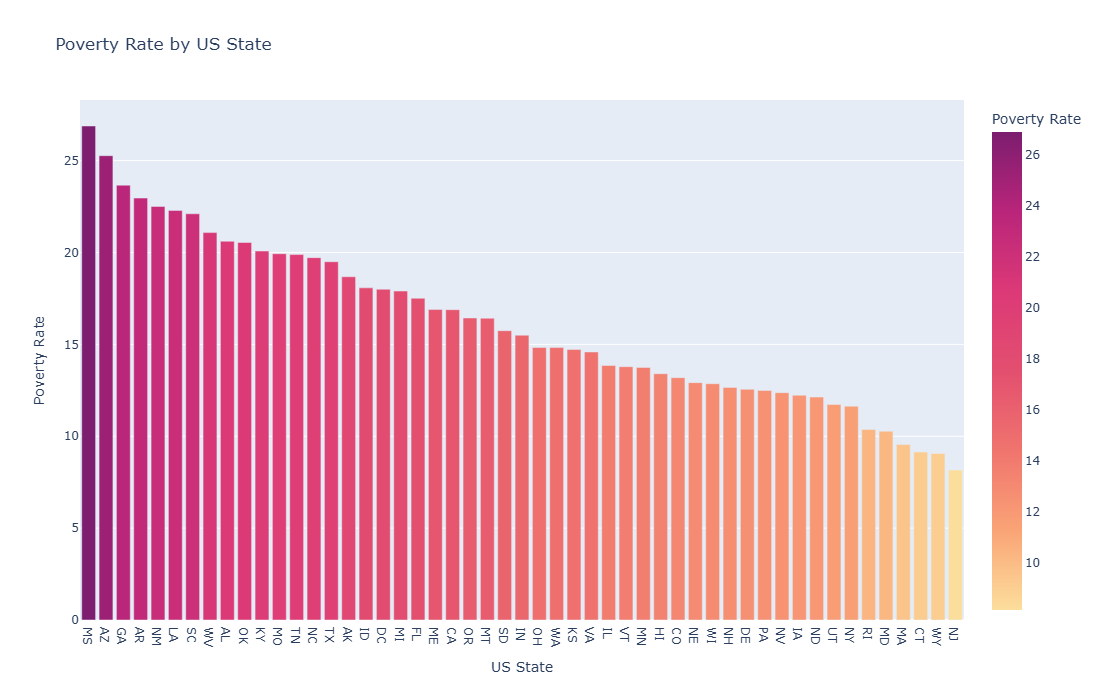

In [16]:
state_poverty_bar = px.bar(state_poverty, x='Geographic Area', y='poverty_rate', color='poverty_rate',
                           title='Poverty Rate by US State', color_continuous_scale='sunsetdark', height=700,
                            labels={'poverty_rate': 'Poverty Rate'})
state_poverty_bar.update_layout(xaxis_title='US State', yaxis_title='Poverty Rate')
state_poverty_bar.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [17]:
# Convert graduation rate to a float
df_completed_hs_pct['percent_completed_hs'] = pd.to_numeric(df_completed_hs_pct['percent_completed_hs'])
df_completed_hs_pct = df_completed_hs_pct.rename(columns={'percent_completed_hs': 'Graduation Rate'})

In [18]:
# Find average rate per state
finish_hs = df_completed_hs_pct.groupby(by='Geographic Area').agg(
    {'Graduation Rate': 'mean'}).reset_index().sort_values(by='Graduation Rate')
print(f'The state with the lowest graduation rate is: {finish_hs.loc[finish_hs['Graduation Rate'].idxmin()]['Geographic Area']}')
print(f'The state with the highest graduation rate is: {finish_hs.loc[finish_hs['Graduation Rate'].idxmax()]['Geographic Area']}')

The state with the lowest graduation rate is: TX
The state with the highest graduation rate is: MA


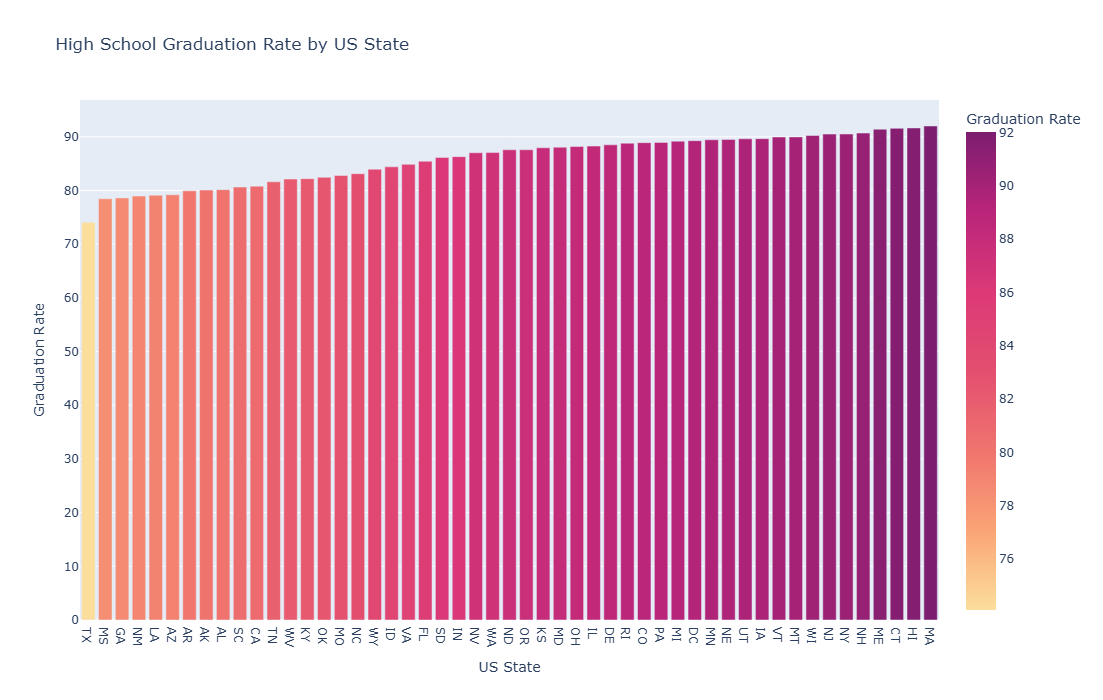

In [19]:
finish_hs_bar = px.bar(finish_hs, x='Geographic Area', y='Graduation Rate', color='Graduation Rate',
                           title='High School Graduation Rate by US State', color_continuous_scale='sunsetdark', height=700)
finish_hs_bar.update_layout(xaxis_title='US State')
finish_hs_bar.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the ratios of poverty and high school graduation move together.  

In [20]:
# Merge dataframes
poverty_hs = state_poverty.merge(finish_hs, on='Geographic Area', how='left')
poverty_hs.head()

,Geographic Area,poverty_rate,Graduation Rate
0,MS,26.88,78.47
1,AZ,25.27,79.22
2,GA,23.66,78.63
3,AR,22.96,79.95
4,NM,22.51,78.97


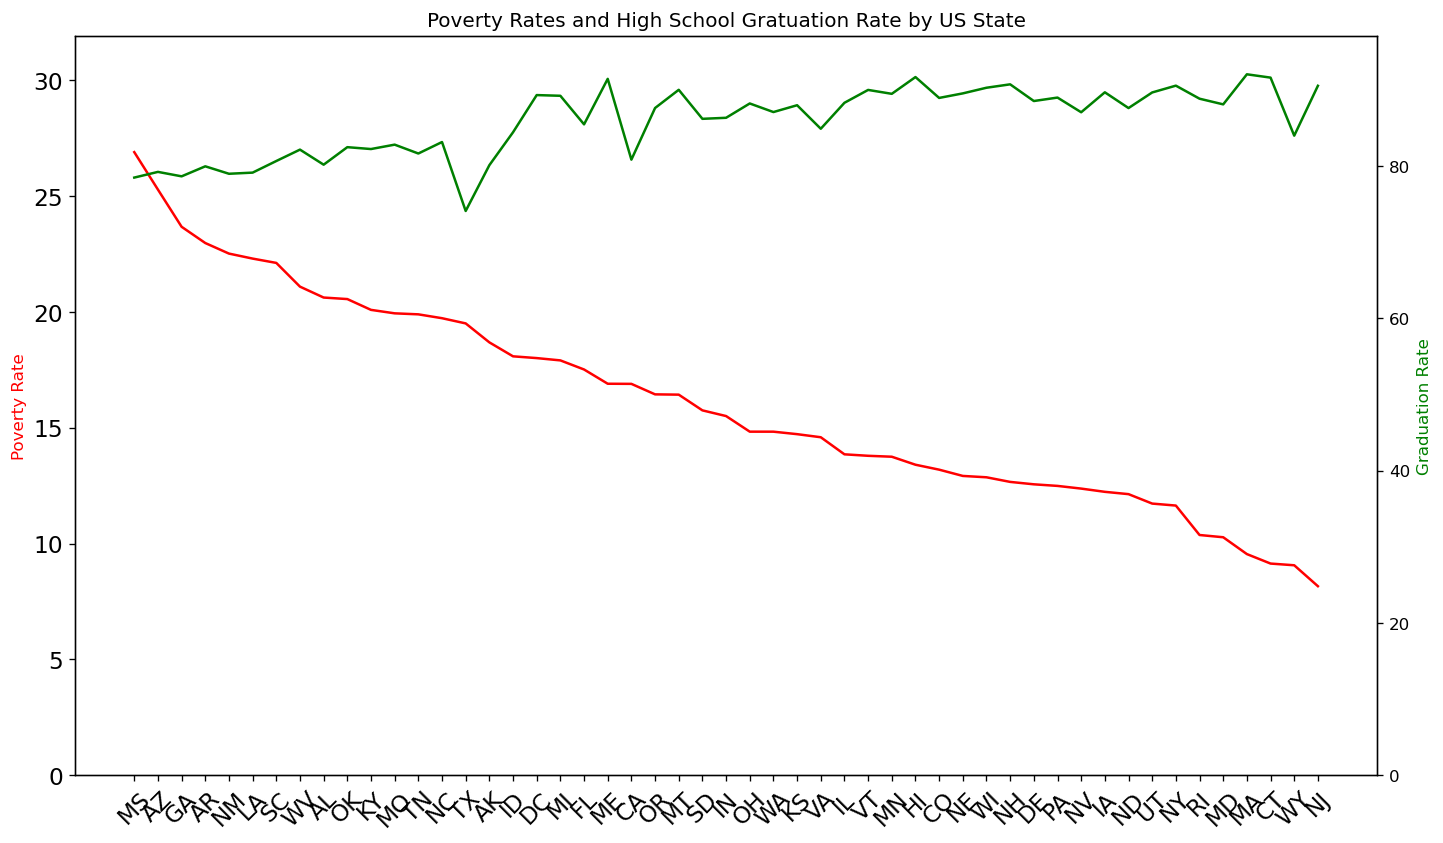

In [21]:
plt.figure(figsize=(14,8), dpi=120)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.title('Poverty Rates and High School Gratuation Rate by US State')

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.set_ylim([0, state_poverty['poverty_rate'].max() + 5])
ax2.set_ylim([0, finish_hs['Graduation Rate'].max()+5])

ax1.plot(poverty_hs['Geographic Area'], poverty_hs.poverty_rate, color="red")
ax2.plot(poverty_hs['Geographic Area'], poverty_hs['Graduation Rate'], color='green')
ax1.set_ylabel("Poverty Rate", color='red')
ax2.set_ylabel("Graduation Rate", color='green')
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

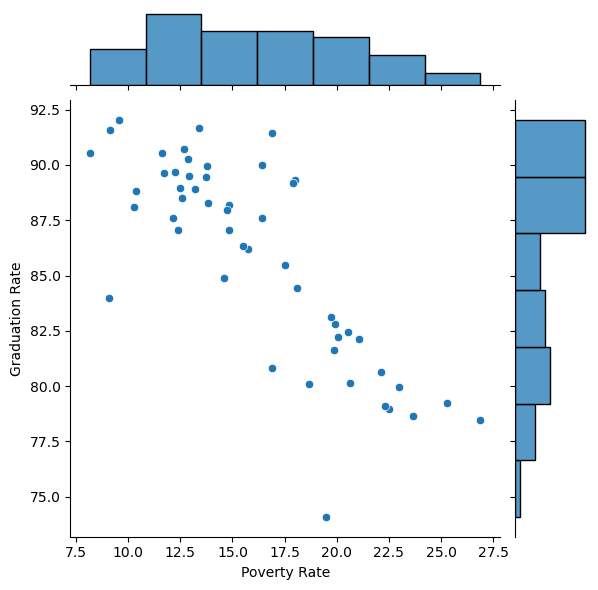

In [22]:
poverty_hs_joint = sns.jointplot(poverty_hs, kind='scatter', x='poverty_rate', y='Graduation Rate')
poverty_hs_joint.set_axis_labels('Poverty Rate', 'Graduation Rate')
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

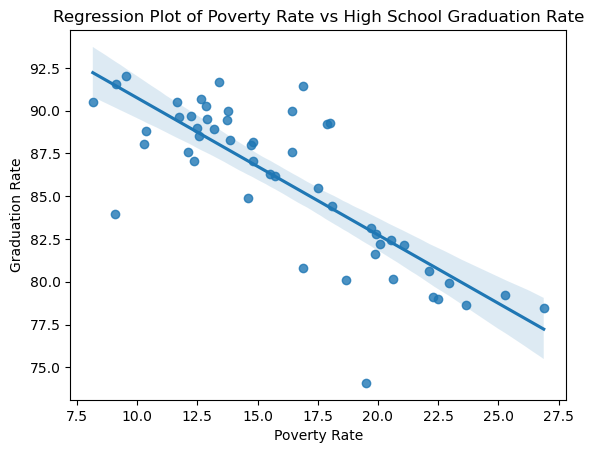

In [23]:
poverty_hs_reg = sns.regplot(poverty_hs, x='poverty_rate', y='Graduation Rate')

poverty_hs_reg.set_xlabel('Poverty Rate')
poverty_hs_reg.set_ylabel('Graduation Rate')
poverty_hs_reg.set_title('Regression Plot of Poverty Rate vs High School Graduation Rate')

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [24]:
# List of column names in racial makeup data
cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

In [25]:
# Convert strings to float
df_share_race_city[cols] = df_share_race_city[cols].apply(pd.to_numeric, errors='coerce')

In [26]:
# Find the average of each race per state
avg_per_race = df_share_race_city.groupby(by='Geographic area').agg({
    'share_white': 'mean',
    'share_black': 'mean', 
    'share_native_american': 'mean',
    'share_asian': 'mean',
    'share_hispanic': 'mean',}).reset_index()
avg_per_race = avg_per_race.rename(columns={'Geographic area': 'State', 'share_white': 'White', 'share_black': 'Black', 'share_native_american': 'Native American',
                                            'share_asian': 'Asian', 'share_hispanic': 'Hispanic'})
avg_per_race.head()

,State,White,Black,Native American,Asian,Hispanic
0,AK,45.65,0.57,45.86,1.39,2.15
1,AL,72.51,23.32,0.66,0.48,2.98
2,AR,78.45,16.30,0.76,0.48,4.27
3,AZ,59.93,0.95,28.59,0.73,20.14
4,CA,71.87,2.69,1.72,5.57,29.65


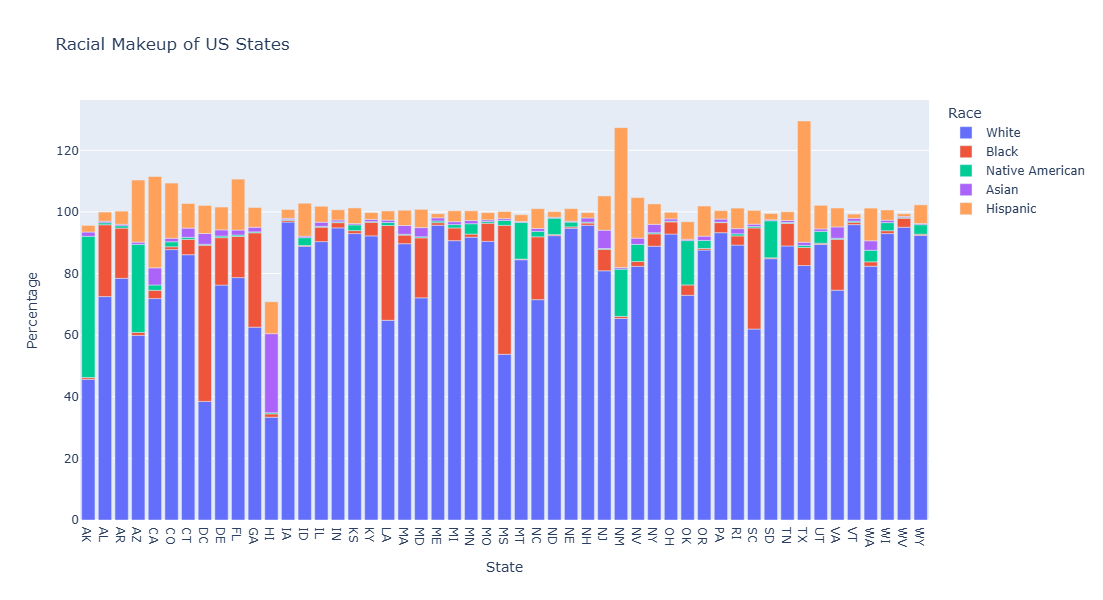

In [27]:
state_race_bar = px.bar(avg_per_race, x='State', y=['White', 'Black', 'Native American',
                                                    'Asian', 'Hispanic'],
                        title='Racial Makeup of US States', height=600)
state_race_bar.update_layout(xaxis_title='State', yaxis_title='Percentage', legend_title_text='Race')
state_race_bar.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [28]:
# Dictionary to substitute words in for letters
race_map = {'W': 'White',
            'B': 'Black',
            'H': 'Hispanic',
            'A': 'Asian',
            'N': 'Native American',
            'O': 'Other',
           'unknown': 'Unknown'}

In [29]:
race_fatality = df_fatalities['race'].value_counts().reset_index()
race_fatality['race'] = race_fatality['race'].map(race_map)
race_fatality

,race,count
0,White,1201
1,Black,618
2,Hispanic,423
3,Unknown,195
4,Asian,39
5,Native American,31
6,Other,28


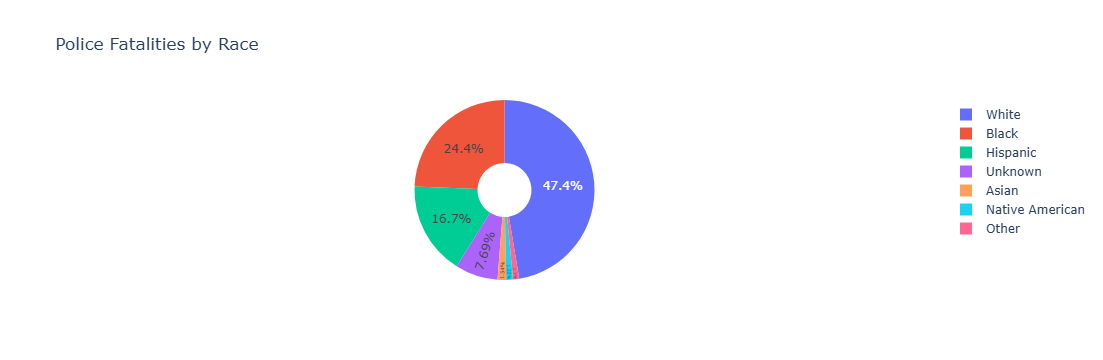

In [30]:
race_fatality_pie = px.pie(race_fatality, values='count', title='Police Fatalities by Race', 
                           names='race', hole=0.3)
race_fatality_pie.update_traces(textposition='inside', textinfo='percent')
race_fatality_pie.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [31]:
# Count number of fatalities per gender
gender_fatality = df_fatalities['gender'].value_counts().reset_index()
gender_fatality

,gender,count
0,M,2428
1,F,107


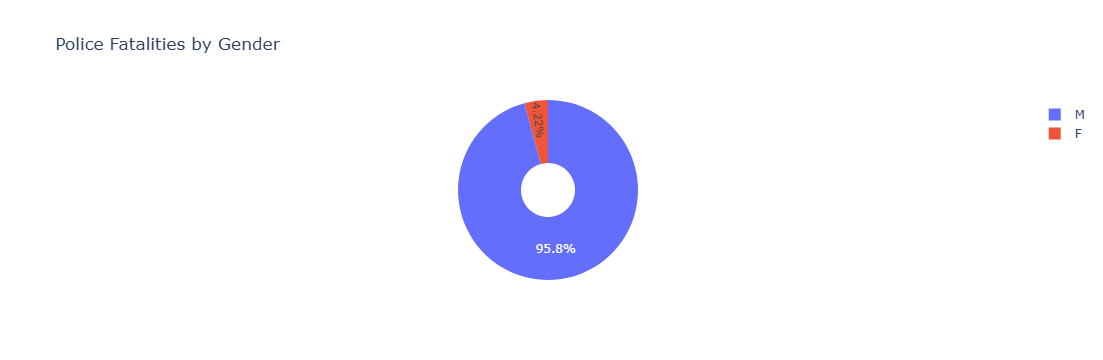

In [32]:
gender_fatality_pie = px.pie(gender_fatality, values='count', title='Police Fatalities by Gender', 
                           names='gender', hole=0.3)
gender_fatality_pie.update_traces(textposition='inside', textinfo='percent')
gender_fatality_pie.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [33]:
fatality_type = df_fatalities.manner_of_death.value_counts().reset_index()
fatality_type

,manner_of_death,count
0,shot,2363
1,shot and Tasered,172


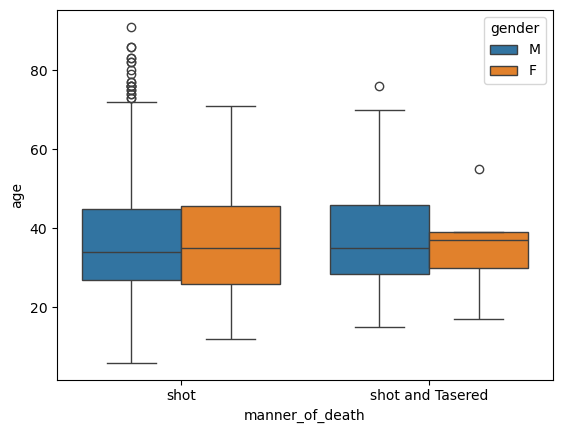

In [34]:
age_gender_box = sns.boxplot(data=df_fatalities, x='manner_of_death', y='age', hue='gender')
plt.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [35]:
armed_fatality = df_fatalities['armed'].value_counts().reset_index()
top_10_armed = armed_fatality[:10]
top_10_armed

,armed,count
0,gun,1398
1,knife,373
2,vehicle,177
3,unarmed,171
4,undetermined,126
5,toy weapon,104
6,machete,18
7,unknown weapon,18
8,ax,9
9,Taser,9


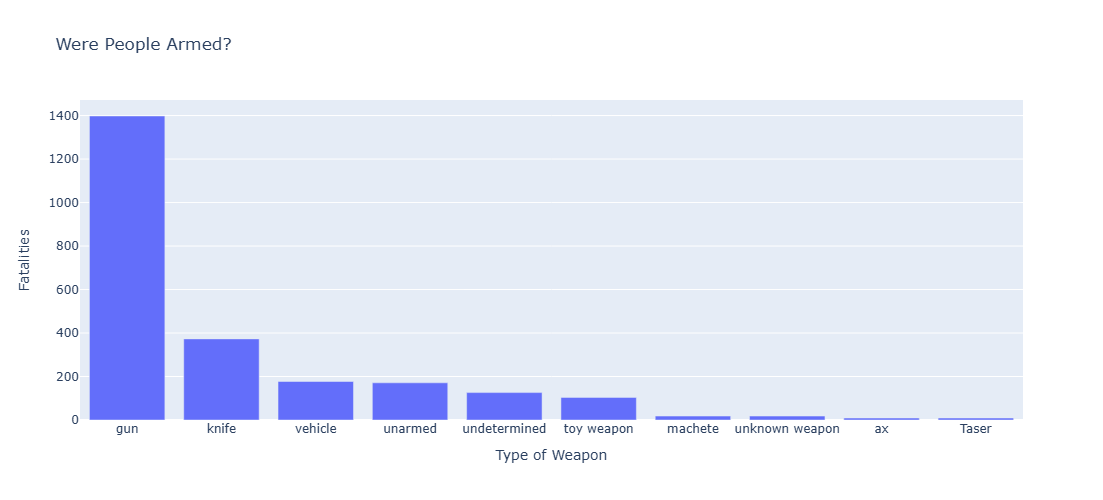

In [36]:
armed_fatality_bar = px.bar(top_10_armed, x='armed', y='count', height=500, title='Were People Armed?')
armed_fatality_bar.update_layout(xaxis_title='Type of Weapon', yaxis_title='Fatalities')
armed_fatality_bar.show()

In [37]:
total_deaths = armed_fatality['count'].sum()
unarmed_count = armed_fatality.loc[armed_fatality['armed'] == 'unarmed', 'count'].iloc[0]
unarmed_pct = (unarmed_count / total_deaths) * 100

print(f'The total number of police related fatalities was: {total_deaths}')
print(f'The number of police related fatalities where the assailant was unarmed: {unarmed_count}')
print(f'This makes up {unarmed_pct:.2f}% of the total number of police related fatalities.')

The total number of police related fatalities was: 2535
The number of police related fatalities where the assailant was unarmed: 171
This makes up 6.75% of the total number of police related fatalities.


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [38]:
under_25 = df_fatalities[df_fatalities['age'] < 25]
under_25_pct = len(under_25) / len(df_fatalities) * 100
print(f'The percentage of people killed under 25 was {under_25_pct:.2f}%')

The percentage of people killed under 25 was 17.75%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

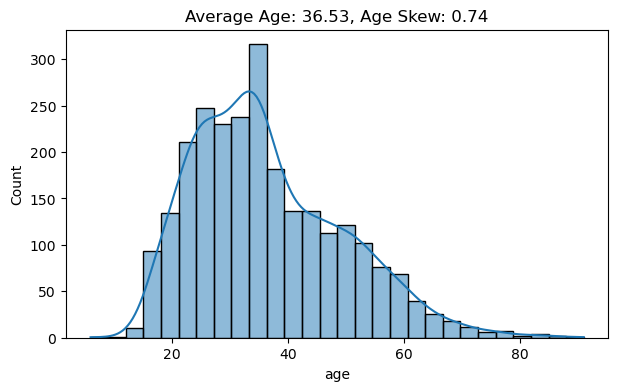

In [39]:
age_skew = round(df_fatalities.age.skew(), 2)
avg_age_all = round(df_fatalities.age.mean(), 2)
plt.figure(figsize=(7,4))
age_histo = sns.histplot(df_fatalities, x='age', binwidth=3, kde=True)
plt.title(f'Average Age: {avg_age_all}, Age Skew: {age_skew}')
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

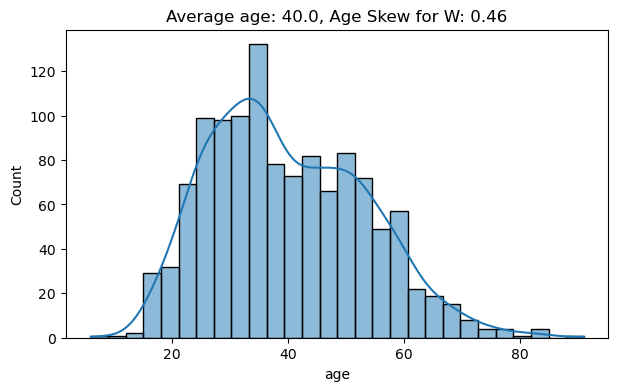

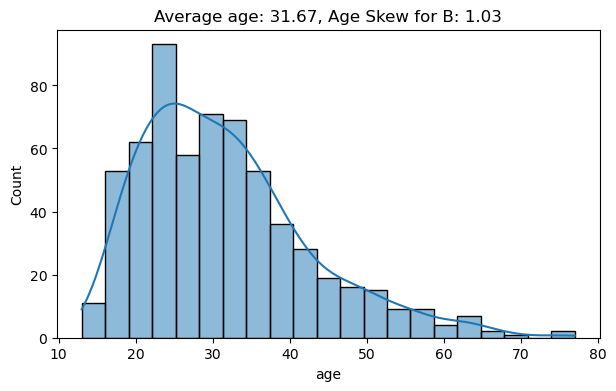

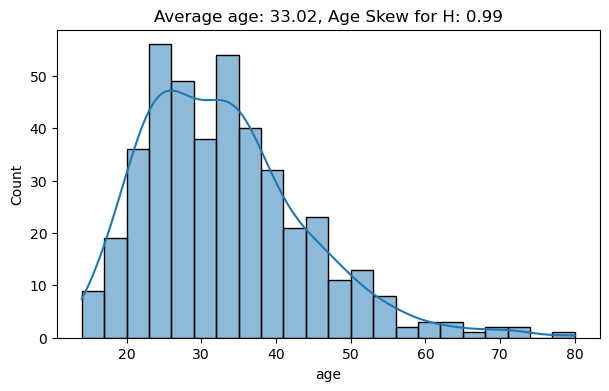

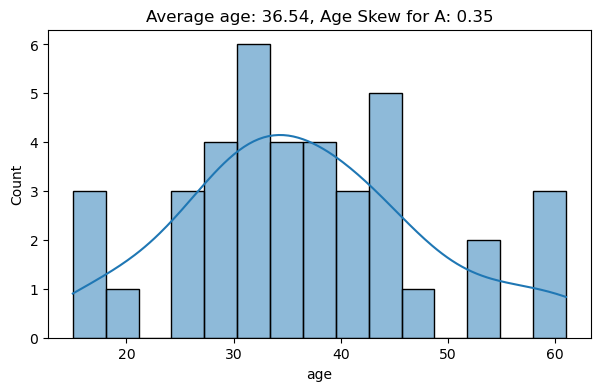

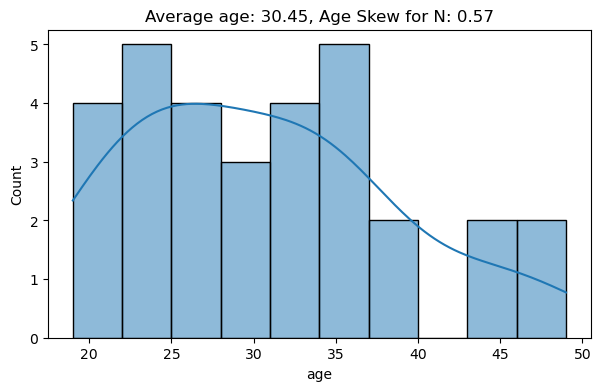

In [40]:
races = ['W', 'B', 'H', 'A', 'N']
for r in races:
    target_race = df_fatalities[df_fatalities['race'] == r]
    race_age_skew = round(target_race.age.skew(), 2)
    avg_age = round(target_race['age'].mean(), 2)
    plt.figure(figsize=(7,4))
    histo = sns.histplot(target_race, x='age', binwidth=3, kde=True)
    plt.title(f'Average age: {avg_age}, Age Skew for {r}: {race_age_skew}')
    plt.show()

In [41]:
# All of the graphs have a positive right skew
# Black deaths seem to have the highest concentration of deaths among people in the late teens and early 20s
# The distributions appear to be similar for whites, blacks, and hispanics

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

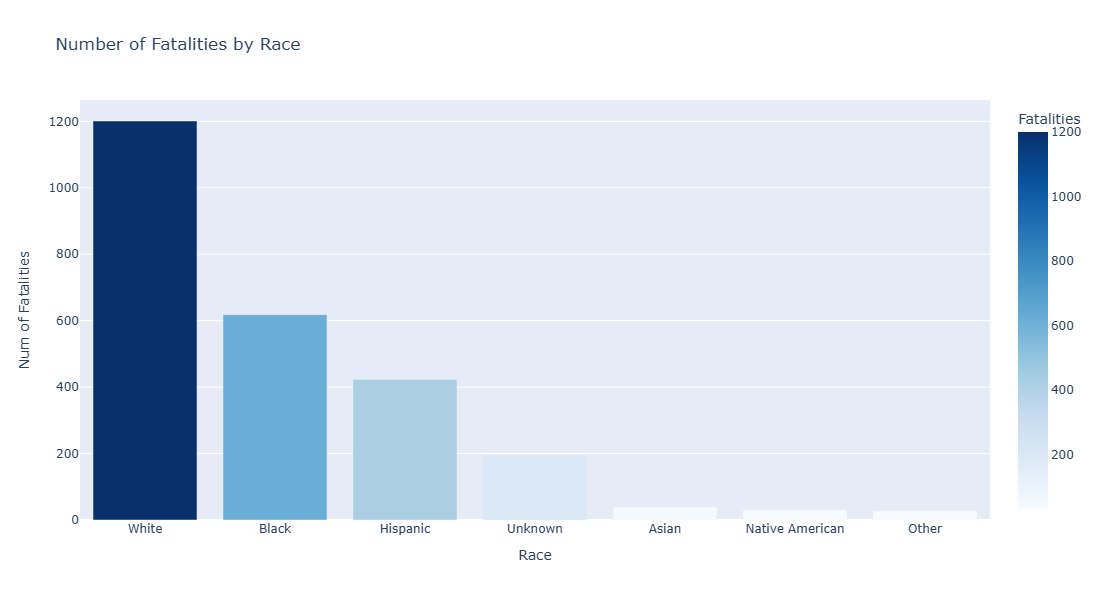

In [42]:
total_race_fat = px.bar(race_fatality, x='race', y='count', color='count', title='Number of Fatalities by Race', height=600, 
                        color_continuous_scale='blues')
total_race_fat.update_layout(xaxis_title='Race', yaxis_title='Num of Fatalities', coloraxis_colorbar_title='Fatalities')
total_race_fat.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [43]:
mi = df_fatalities['signs_of_mental_illness'].value_counts().reset_index().rename(columns={'signs_of_mental_illness': 'mental_illness'})
mi

,mental_illness,count
0,False,1902
1,True,633


In [44]:
mi_yes = mi.loc[mi['mental_illness'] == True, 'count'].iloc[0]
mi_pct = (mi_yes / len(df_fatalities)) * 100
print(f'The percentage of people killed by police who have been diagnosed with signs of a mental illness is {mi_pct:.2f}%')

The percentage of people killed by police who have been diagnosed with signs of a mental illness is 24.97%


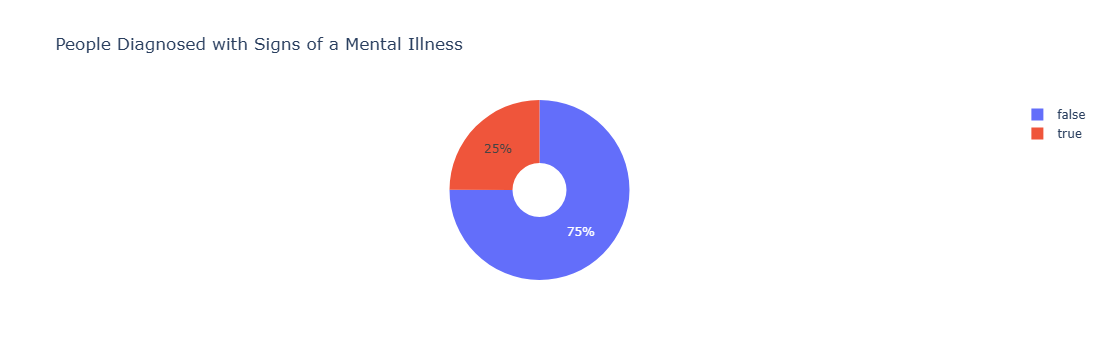

In [45]:
mi_pie = px.pie(mi, values='count', title='People Diagnosed with Signs of a Mental Illness', names='mental_illness',
                hole=0.3)
mi_pie.update_traces(textposition='inside', textinfo='percent')
mi_pie.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [46]:
# Find cities with the most police killings
# Sort by city and state to avoid grouping cities with the same name in different states
fatality_city = df_fatalities.groupby(by=['city', 'state'], as_index=False).agg(
    {'name': 'count'}).rename(columns={'name': 'Fatalities'})
fatality_city = fatality_city.sort_values(by='Fatalities', ascending=False)
fatality_city = fatality_city[:10]
fatality_city

,city,state,Fatalities
805,Los Angeles,CA,39
1083,Phoenix,AZ,31
632,Houston,TX,26
262,Chicago,IL,25
758,Las Vegas,NV,21
1215,San Antonio,TX,20
310,Columbus,OH,17
886,Miami,FL,17
70,Austin,TX,16
1324,St. Louis,MO,15


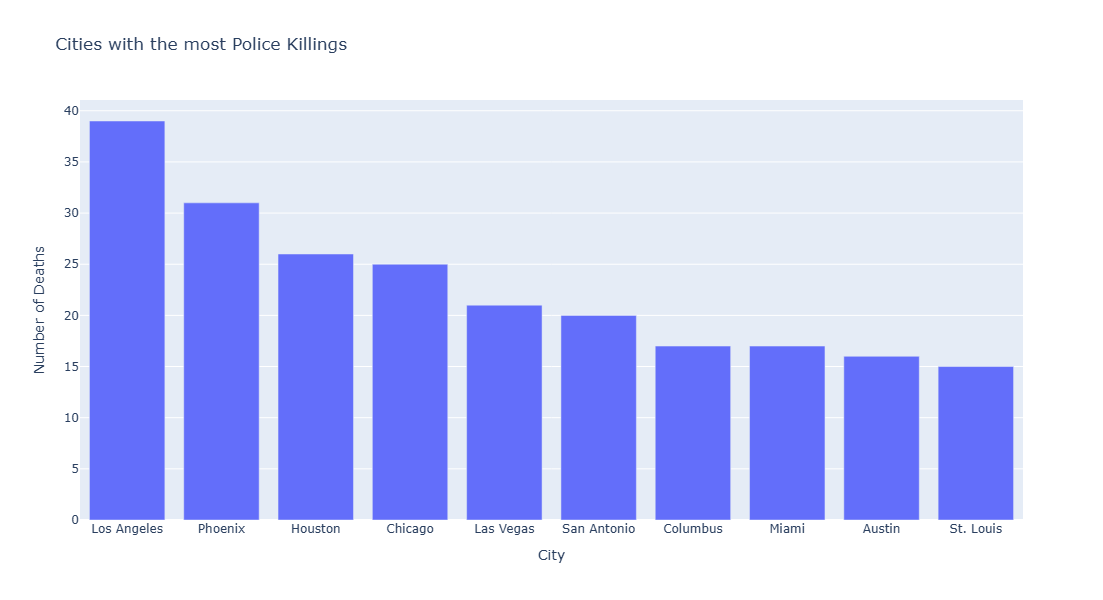

In [47]:
fatality_city_bar = px.bar(fatality_city, x='city', y='Fatalities', title='Cities with the most Police Killings',
                           height=600)
fatality_city_bar.update_layout(xaxis_title='City', yaxis_title='Number of Deaths')
fatality_city_bar.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [48]:
# Replace 'city' suffixes in City column and get rid of extra whitespaces of city race data. 
# 'Phoenix city' -> 'Pheonix'
df_share_race_city['City'] = df_share_race_city['City'].str.replace('city', '').str.strip()

In [49]:
# Double check names
df_share_race_city[df_share_race_city['City'] == 'Phoenix']

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
1201,AZ,Phoenix,65.90,6.50,2.20,3.20,40.80
21341,OR,Phoenix,84.00,0.90,1.50,1.30,15.80


In [50]:
# Merge top 10 cities with race data
top_10_race_city = df_share_race_city.merge(fatality_city, left_on=['City', 'Geographic area'], right_on=['city', 'state'], how='inner')
top_10_race_city = top_10_race_city.drop(['city', 'state'], axis=1)
top_10_race_city

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,Fatalities
0,AZ,Phoenix,65.90,6.50,2.20,3.20,40.80,31
1,CA,Los Angeles,49.80,9.60,0.70,11.30,48.50,39
2,FL,Miami,72.60,19.20,0.30,1.00,70.00,17
3,IL,Chicago,45.00,32.90,0.50,5.50,28.90,25
4,MO,St. Louis,43.90,49.20,0.30,2.90,3.50,15
5,NV,Las Vegas,62.10,11.10,0.70,6.10,31.50,21
6,OH,Columbus,61.50,28.00,0.30,4.10,5.60,17
7,TX,Austin,68.30,8.10,0.90,6.30,35.10,16
8,TX,Houston,50.50,23.70,0.70,6.00,43.80,26
9,TX,San Antonio,72.60,6.90,0.90,2.40,63.20,20


In [51]:
for race in top_10_race_city:
    top_10_race_city['white'] = round((top_10_race_city['share_white'] / 100) * top_10_race_city['Fatalities'])
    top_10_race_city['black'] = round((top_10_race_city['share_black'] / 100) * top_10_race_city['Fatalities'])
    top_10_race_city['native american'] = round((top_10_race_city['share_native_american'] / 100) * top_10_race_city['Fatalities'])
    top_10_race_city['asian'] = round((top_10_race_city['share_asian'] / 100) * top_10_race_city['Fatalities'])
    top_10_race_city['hispanic'] = round((top_10_race_city['share_hispanic'] / 100) * top_10_race_city['Fatalities'])

top_10_race_city

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,Fatalities,white,black,native american,asian,hispanic
0,AZ,Phoenix,65.90,6.50,2.20,3.20,40.80,31,20.00,2.00,1.00,1.00,13.00
1,CA,Los Angeles,49.80,9.60,0.70,11.30,48.50,39,19.00,4.00,0.00,4.00,19.00
2,FL,Miami,72.60,19.20,0.30,1.00,70.00,17,12.00,3.00,0.00,0.00,12.00
3,IL,Chicago,45.00,32.90,0.50,5.50,28.90,25,11.00,8.00,0.00,1.00,7.00
4,MO,St. Louis,43.90,49.20,0.30,2.90,3.50,15,7.00,7.00,0.00,0.00,1.00
5,NV,Las Vegas,62.10,11.10,0.70,6.10,31.50,21,13.00,2.00,0.00,1.00,7.00
6,OH,Columbus,61.50,28.00,0.30,4.10,5.60,17,10.00,5.00,0.00,1.00,1.00
7,TX,Austin,68.30,8.10,0.90,6.30,35.10,16,11.00,1.00,0.00,1.00,6.00
8,TX,Houston,50.50,23.70,0.70,6.00,43.80,26,13.00,6.00,0.00,2.00,11.00
9,TX,San Antonio,72.60,6.90,0.90,2.40,63.20,20,15.00,1.00,0.00,0.00,13.00


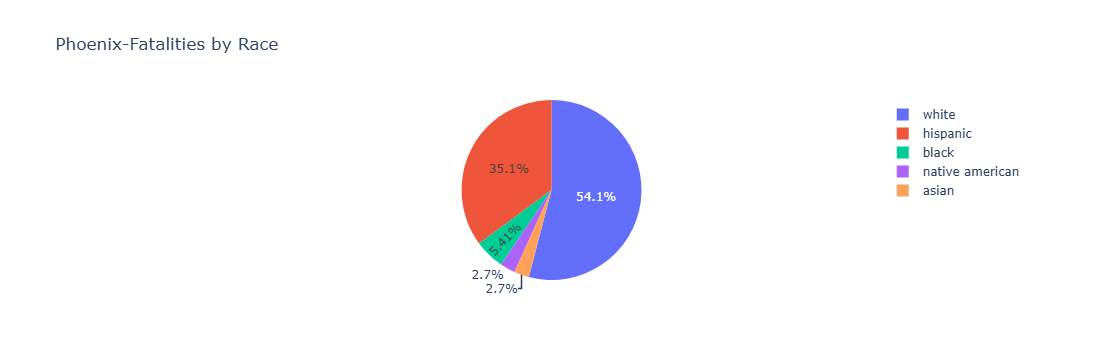

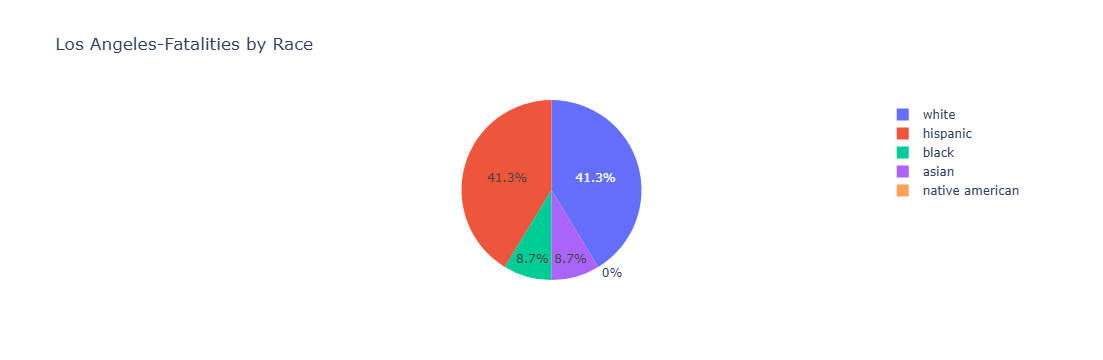

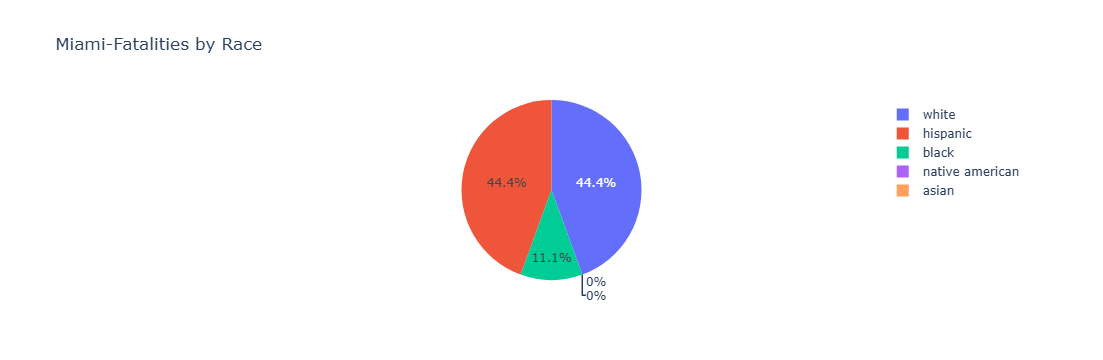

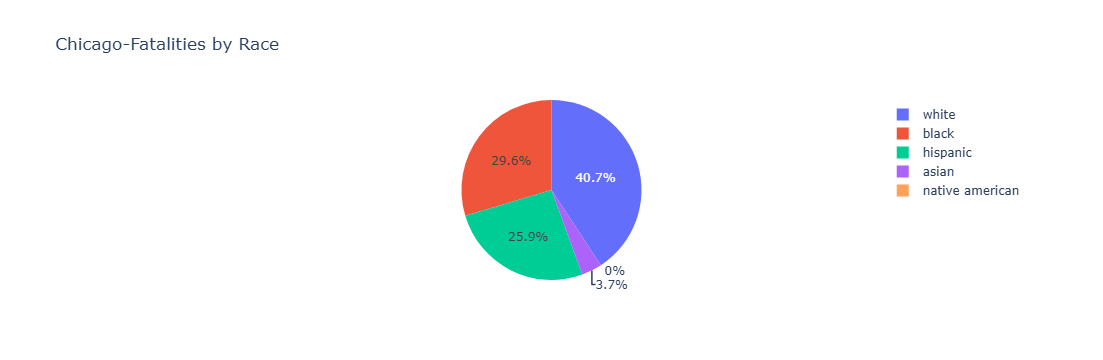

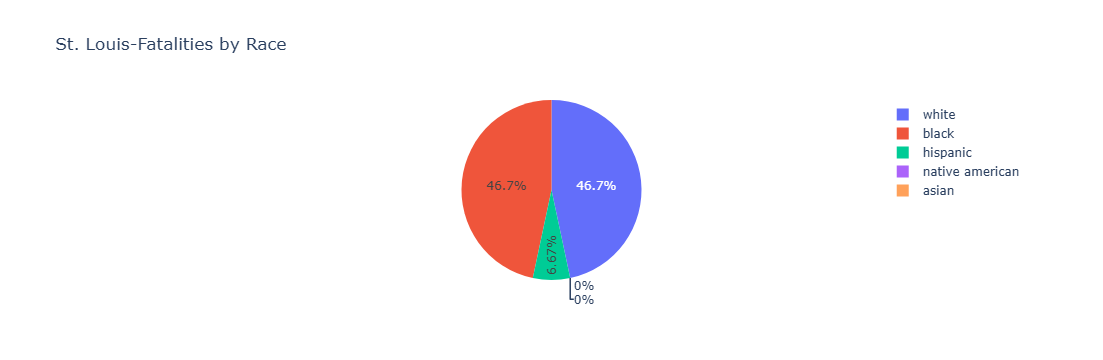

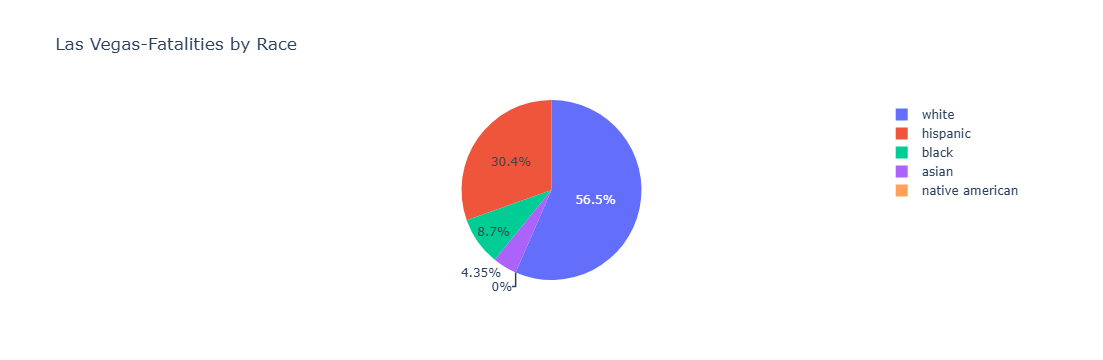

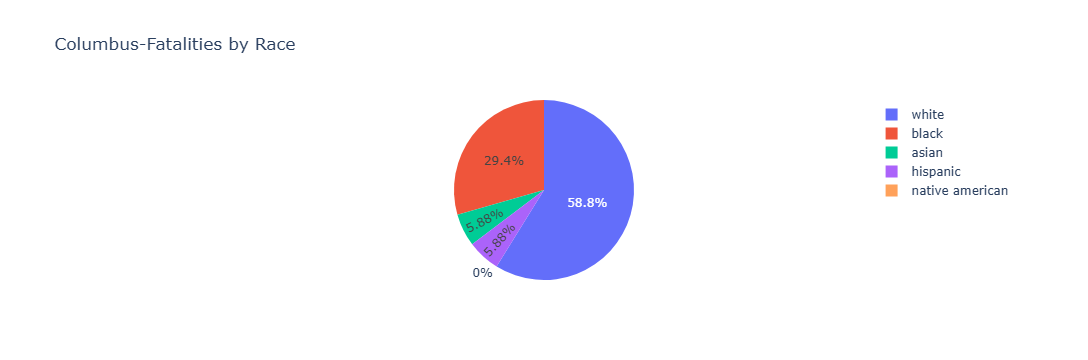

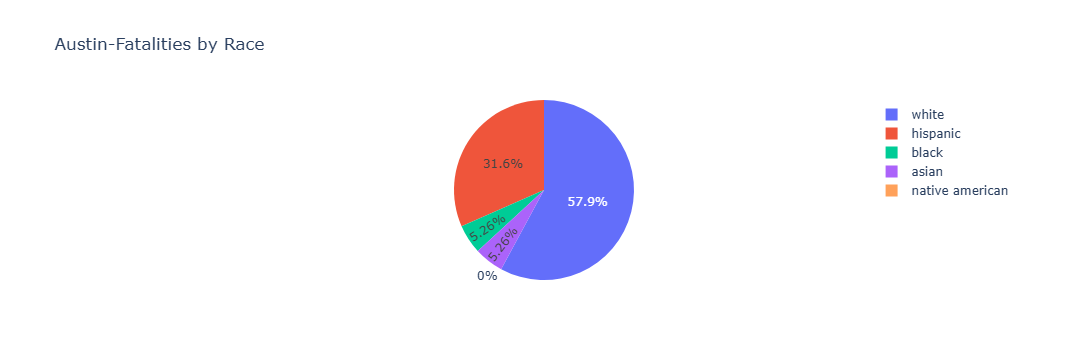

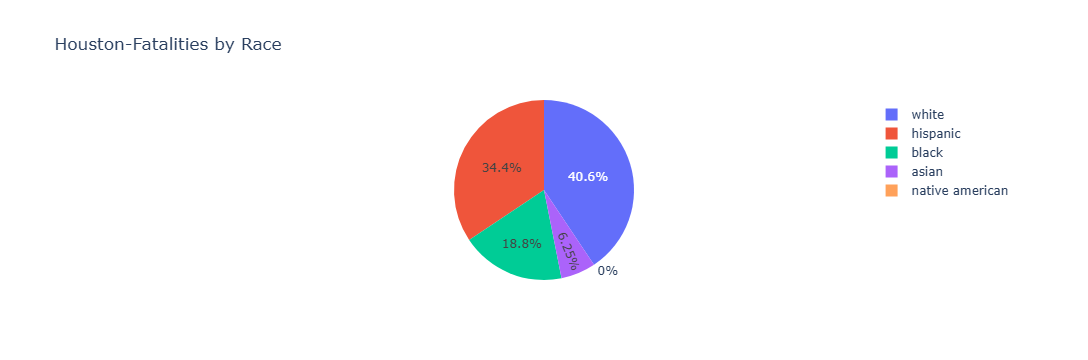

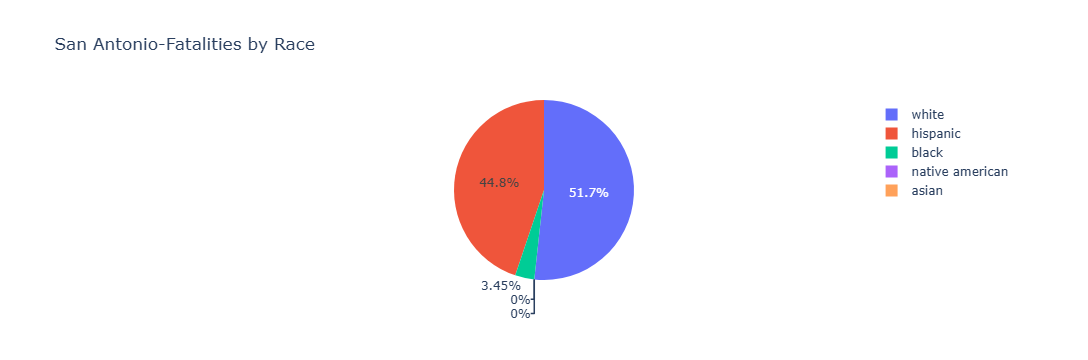

In [52]:
for _, row in top_10_race_city.iterrows():
    city = row['City']
    races = ['white', 'black', 'native american', 'asian', 'hispanic']
    values = [row[r] for r in races]
    df_city = pd.DataFrame({'Race': races, 'Fatalities': values})
    
    race_city_pie = px.pie(df_city, names='Race', values='Fatalities', title=f'{city}-Fatalities by Race')
    race_city_pie.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [53]:
# Find number of killings per state
us_state_killings = df_fatalities.groupby(by='state').agg(
    {'name': 'count'}).rename(columns={'name': 'Killings'}).reset_index()
us_state_killings = us_state_killings.sort_values(by='Killings', ascending=False)
# Sum of killings should match len of fatalities data
len(df_fatalities) == us_state_killings.Killings.sum()

True

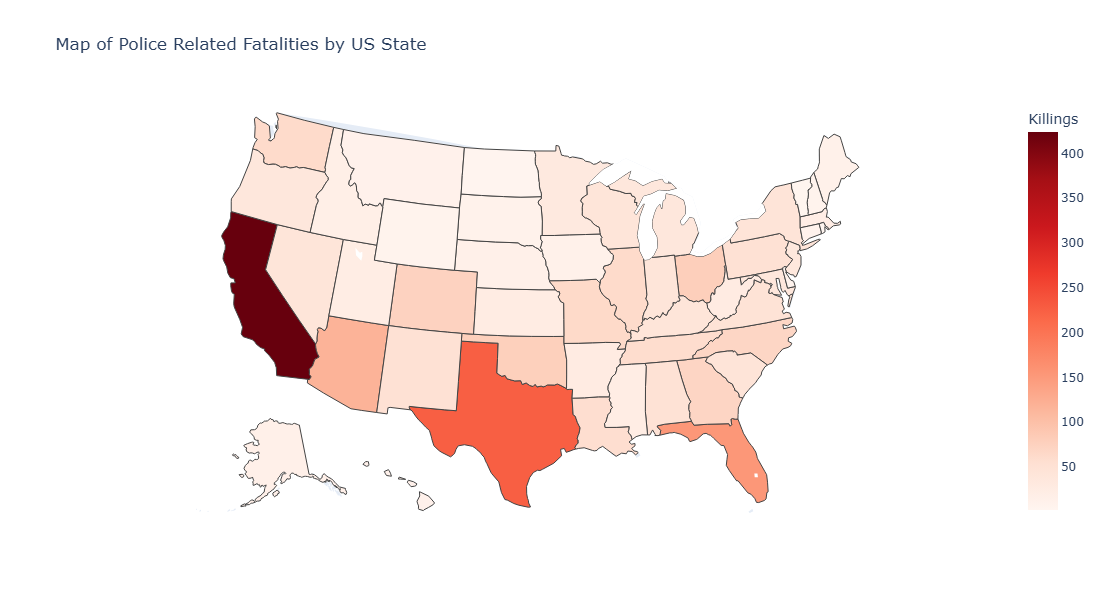

In [54]:
state_killings_map = px.choropleth(us_state_killings, locations='state', locationmode='USA-states', 
                                   color='Killings', color_continuous_scale='reds', height=600, 
                                   title='Map of Police Related Fatalities by US State')
state_killings_map.update_layout(geo_scope='usa')
state_killings_map.show()

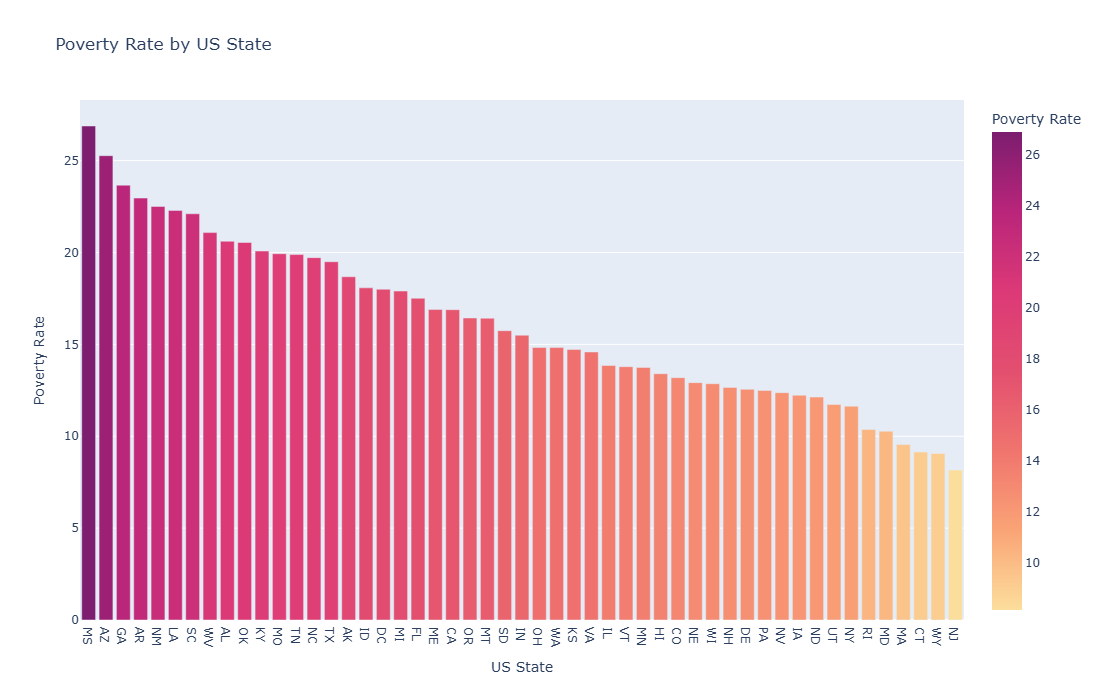

In [55]:
# Place earlier poverty chart here for easier comparison
state_poverty_bar.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [56]:
# Convert date column to datetime format
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'], format='%d/%m/%y')
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,2015-01-02,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,2015-01-02,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,2015-01-03,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,2015-01-04,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,2015-01-04,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [57]:
# Count killings per month
monthly_killings = df_fatalities.groupby(by=df_fatalities.date.dt.strftime('%Y-%m')).agg(
    {'name': 'count'}).rename(columns={'name': 'Killings'}).reset_index()
monthly_killings.head()

,date,Killings
0,2015-01,76
1,2015-02,77
2,2015-03,92
3,2015-04,84
4,2015-05,71


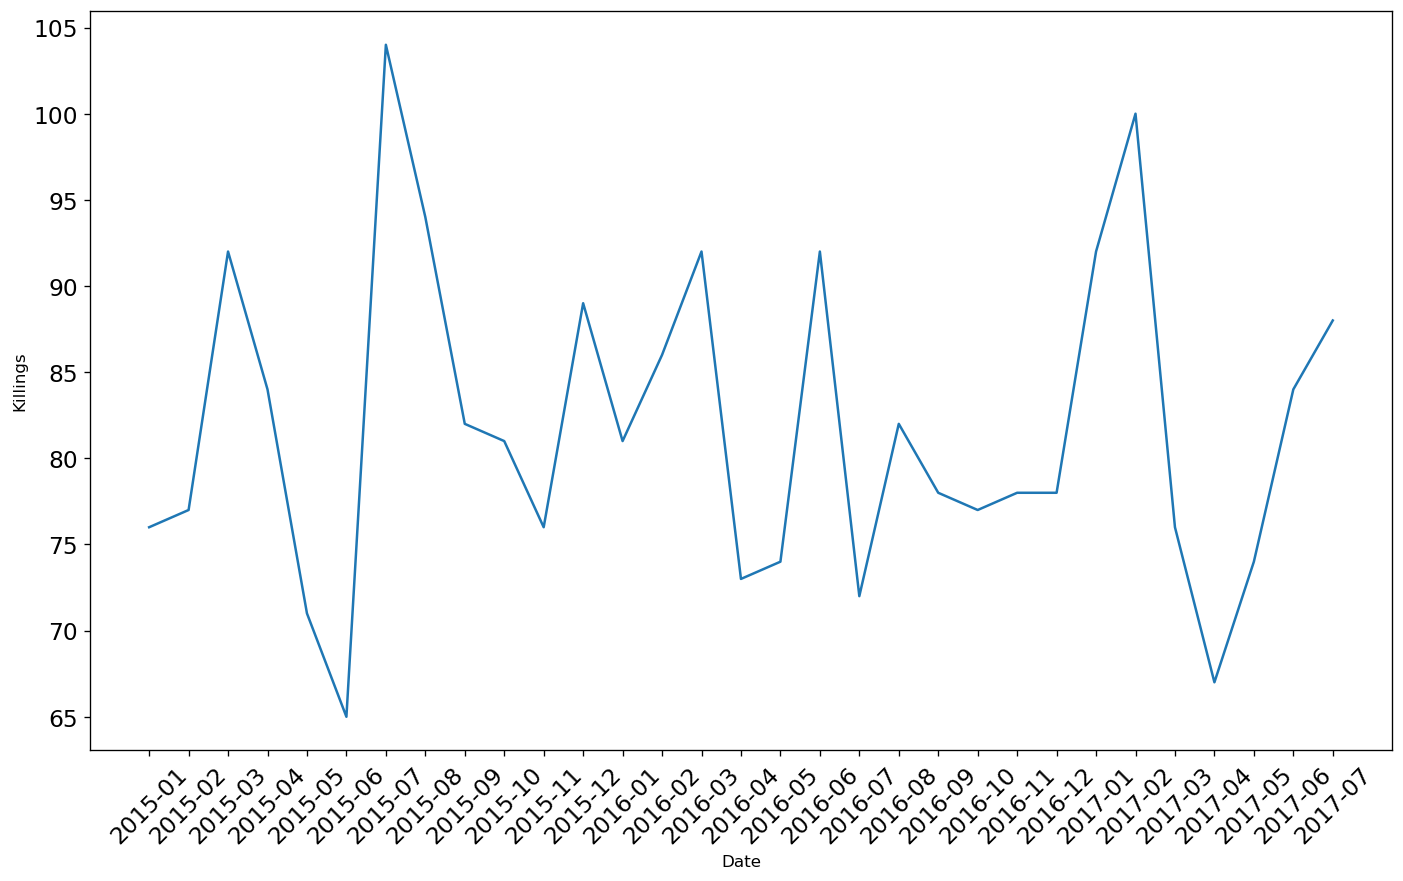

In [58]:
# Plot killings over the 2 year time span
plt.figure(figsize=(14,8), dpi=120)
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)

ax = plt.gca()

plt.plot(monthly_killings['date'], monthly_killings['Killings'])
ax.set_xlabel('Date')
ax.set_ylabel('Killings')
plt.show()

In [59]:
# Not much trend monthly, so let's compare yearly
yearly_killings = df_fatalities.groupby(by=df_fatalities.date.dt.year).agg(
    {'name': 'count'}).reset_index()
yearly_killings = yearly_killings.rename(columns={'date': 'Year', 'name': 'Killings'})
yearly_killings.head()

,Year,Killings
0,2015,991
1,2016,963
2,2017,581


In [60]:
yearly_killings_bar = px.bar(yearly_killings, x=['2015', '2016', '2017'], y='Killings', height=600, title='Number of Yearly Killings')
yearly_killings_bar.update_layout(xaxis_title='Year')
yearly_killings_bar.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).